In [1]:
!nvidia-smi

Tue Sep  1 18:24:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q opencv-python-headless onnxruntime-gpu matplotlib pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.2/202.2 MB 6.3 MB/s eta 0:00:00


In [3]:
import cv2
import onnxruntime as ort

print("OpenCV:", cv2.__version__)
print("ONNX Runtime:", ort.__version__)
print("Available providers:", ort.get_available_providers())

OpenCV: 5.0.0
ONNX Runtime: 1.29.0
Available providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [4]:
!wget -O nafnet.onnx "https://drive.google.com/uc?export=download&id=1ZLRhkpCekNruJZggVpBgSoCx3k7bJ-5v"

--2026-09-01 18:25:49--  https://drive.google.com/uc?export=download&id=1ZLRhkpCekNruJZggVpBgSoCx3k7bJ-5v
Resolving drive.google.com (drive.google.com)... 74.125.137.100, 74.125.137.113, 74.125.137.139, ...
Connecting to drive.google.com (drive.google.com)|74.125.137.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1ZLRhkpCekNruJZggVpBgSoCx3k7bJ-5v&export=download [following]
--2026-09-01 18:25:49--  https://drive.usercontent.google.com/download?id=1ZLRhkpCekNruJZggVpBgSoCx3k7bJ-5v&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.45.1, 2607:f8b0:4007:808::2001
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.45.1|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 91736251 (87M) [application/octet-stream]
Saving to: ‘nafnet.onnx’

nafnet.onnx         100%[===================>]  87.49M  49.5MB/s    i

In [5]:
!ls -lh nafnet.onnx

-rw-r--r-- 1 root root 88M May 27  2025 nafnet.onnx


In [6]:
import onnxruntime as ort

providers = [
    "CUDAExecutionProvider",
    "CPUExecutionProvider"
]

session = ort.InferenceSession(
    "nafnet.onnx",
    providers=providers
)

print("Providers:", session.get_providers())

Providers: ['CPUExecutionProvider']


In [7]:
input_info = session.get_inputs()[0]
output_info = session.get_outputs()[0]

print("Input name:", input_info.name)
print("Input shape:", input_info.shape)
print("Input type:", input_info.type)

print()

print("Output name:", output_info.name)
print("Output shape:", output_info.shape)
print("Output type:", output_info.type)

Input name: lq
Input shape: ['batch_size', 3, 'height', 'width']
Input type: tensor(float)

Output name: output
Output shape: ['batch_size', 'Sliceoutput_dim_1', 'height', 'width']
Output type: tensor(float)


In [14]:
from google.colab import files

uploaded = files.upload()

Saving blur.jpg to blur.jpg


Image size: (516, 387)


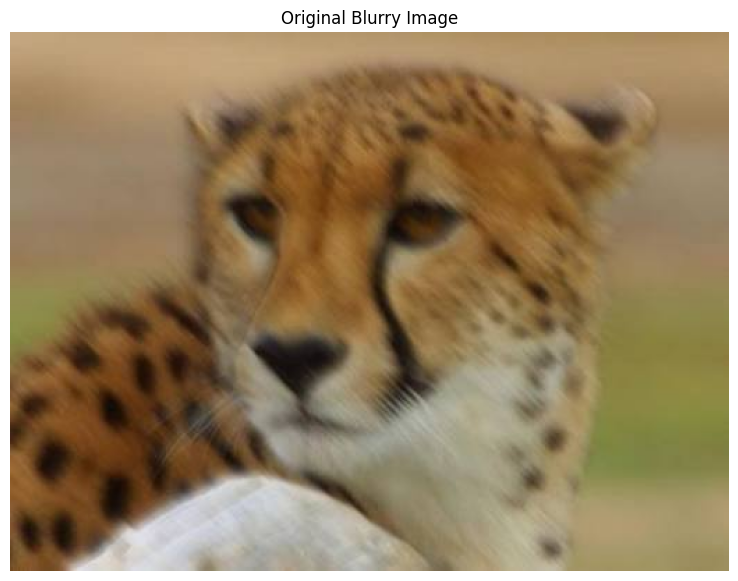

In [15]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

image_path = list(uploaded.keys())[0]

image = Image.open(image_path).convert("RGB")

print("Image size:", image.size)

plt.figure(figsize=(10, 7))
plt.imshow(image)
plt.axis("off")
plt.title("Original Blurry Image")
plt.show()

In [16]:
import numpy as np

img = np.array(image).astype(np.float32) / 255.0

# HWC → CHW
img = np.transpose(img, (2, 0, 1))

# Add batch dimension
input_tensor = np.expand_dims(img, axis=0)

print("Input tensor shape:", input_tensor.shape)

Input tensor shape: (1, 3, 387, 516)


In [17]:
output = session.run(
    [output_info.name],
    {input_info.name: input_tensor}
)[0]

print("Output shape:", output.shape)

Output shape: (1, 3, 387, 516)


In [18]:
output = np.squeeze(output, axis=0)

# CHW → HWC
output = np.transpose(output, (1, 2, 0))

# Keep values between 0 and 1
output = np.clip(output, 0, 1)

# Convert to 8-bit image
output_image = (output * 255).astype(np.uint8)

print("Output image shape:", output_image.shape)

Output image shape: (387, 516, 3)


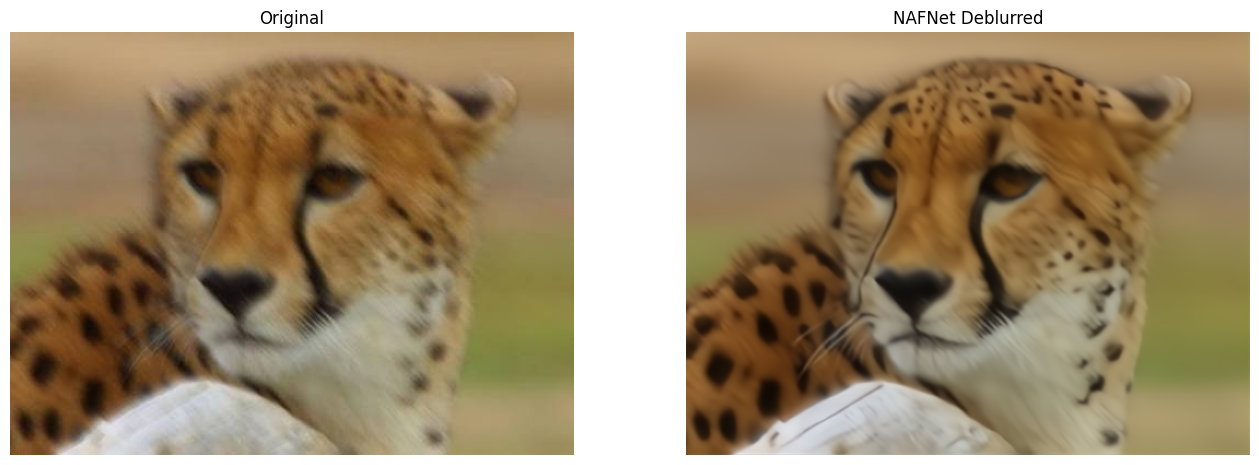

In [19]:
plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(output_image)
plt.title("NAFNet Deblurred")
plt.axis("off")

plt.show()